In [ ]:
# Title: 06_Xu_ElasticNet_noLOOCV_heart.ipynb
# Author: Lajoyce Mboning
# Date:2025
# Related publication: Emma K. Costa, and Jingxun Chen, in prep


# Description - Run the EN clock on Xu et al

# Set Up

In [ ]:
from numpy import mean
from numpy import std
from numpy import absolute
import pandas as pd
# use automatically configured elastic net algorithm
from numpy import arange
from sklearn.model_selection import cross_val_score
#from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import ElasticNet
#from sklearn.linear_model import ElasticNet
from sklearn.model_selection import RepeatedKFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
import statsmodels.api as sm
lowess = sm.nonparametric.lowess
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from scipy import stats
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

In [ ]:
#allow Google CoLab to have access to your drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# set working dir
# Get current notebook's directory
notebook_dir = '/content/drive/My Drive/african_killifish_atlas/revisions/CodeCheck_revisions/Xu_model_outputs/ElasticNet/'

# Set working directory (here it's just confirming it's already set)
os.chdir(notebook_dir)

# Load and format Xu data - Heart

In [ ]:
df_counts_heart = pd.read_csv("../../Data_from_Others/AlanXu_Aging/CountsNormDESeq2_AlanXuAging_Heart_250605.csv")

df_counts_heart.head(5)

,Unnamed: 0,Heart_20,Heart_19,Heart_18,Heart_17,Heart_16,Heart_15,Heart_14,Heart_13,Heart_12,...,Heart_10,Heart_9,Heart_8,Heart_7,Heart_6,Heart_5,Heart_4,Heart_3,Heart_2,Heart_1
0,nadsyn1,151.327568,182.330309,164.475709,167.432999,191.037771,154.890147,159.820750,156.610045,192.153323,...,180.069409,147.666303,178.958188,219.168922,175.501225,170.160069,187.644093,144.813586,196.799505,213.422826
1,dnaja3,316.517203,406.387952,365.892485,351.714601,456.151413,454.821935,520.065359,405.097982,390.505140,...,361.837587,355.372752,464.032287,489.000007,459.173017,350.383367,475.429853,556.893424,473.041013,536.999368
2,f2r,128.224123,138.788743,169.753004,90.561245,62.379680,127.135265,158.956854,231.782866,68.183437,...,47.565504,50.303905,50.360093,35.243244,33.113439,56.720023,52.501456,76.666016,43.332001,57.830701
3,LOC107382877,145.551707,143.324323,168.873455,124.258452,109.164441,141.460366,117.489848,164.962580,167.359346,...,107.022385,90.871571,82.734439,145.378380,112.585692,80.505839,79.724434,93.702909,133.607004,66.092230
4,fezf1,0.000000,0.000000,0.000000,0.000000,2.599153,0.000000,1.727792,2.088134,1.770998,...,0.000000,1.622707,3.597150,2.202703,8.830250,1.829678,7.777994,4.259223,5.416500,5.507686


In [ ]:
df_counts_heart.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_counts_heart.head(3)

,sample,Heart_20,Heart_19,Heart_18,Heart_17,Heart_16,Heart_15,Heart_14,Heart_13,Heart_12,...,Heart_10,Heart_9,Heart_8,Heart_7,Heart_6,Heart_5,Heart_4,Heart_3,Heart_2,Heart_1
0,nadsyn1,151.327568,182.330309,164.475709,167.432999,191.037771,154.890147,159.820750,156.610045,192.153323,...,180.069409,147.666303,178.958188,219.168922,175.501225,170.160069,187.644093,144.813586,196.799505,213.422826
1,dnaja3,316.517203,406.387952,365.892485,351.714601,456.151413,454.821935,520.065359,405.097982,390.505140,...,361.837587,355.372752,464.032287,489.000007,459.173017,350.383367,475.429853,556.893424,473.041013,536.999368
2,f2r,128.224123,138.788743,169.753004,90.561245,62.379680,127.135265,158.956854,231.782866,68.183437,...,47.565504,50.303905,50.360093,35.243244,33.113439,56.720023,52.501456,76.666016,43.332001,57.830701


In [ ]:
df_counts_heart.set_index("sample", inplace=True)

df_counts_heart.head(3)

,Heart_20,Heart_19,Heart_18,Heart_17,Heart_16,Heart_15,Heart_14,Heart_13,Heart_12,Heart_11,Heart_10,Heart_9,Heart_8,Heart_7,Heart_6,Heart_5,Heart_4,Heart_3,Heart_2,Heart_1
sample,,,,,,,,,,,,,,,,,,,,
nadsyn1,151.327568,182.330309,164.475709,167.432999,191.037771,154.890147,159.820750,156.610045,192.153323,164.843222,180.069409,147.666303,178.958188,219.168922,175.501225,170.160069,187.644093,144.813586,196.799505,213.422826
dnaja3,316.517203,406.387952,365.892485,351.714601,456.151413,454.821935,520.065359,405.097982,390.505140,441.476674,361.837587,355.372752,464.032287,489.000007,459.173017,350.383367,475.429853,556.893424,473.041013,536.999368
f2r,128.224123,138.788743,169.753004,90.561245,62.379680,127.135265,158.956854,231.782866,68.183437,111.790231,47.565504,50.303905,50.360093,35.243244,33.113439,56.720023,52.501456,76.666016,43.332001,57.830701


In [ ]:
df_counts_heart = df_counts_heart.T

df_counts_heart.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
Heart_20,151.327568,316.517203,128.224123,145.551707,0.000000,91.258610,0.000000,4.620689,180.206875,548.706831,...,5.775861,1157.482619,0.0,2.310345,4.620689,4.620689,46.206891,2271.068693,227.568938,69.310336
Heart_19,182.330309,406.387952,138.788743,143.324323,0.000000,65.312349,1.814232,0.000000,270.320558,426.344504,...,18.142319,1129.359377,0.0,3.628464,11.792508,5.442696,34.470407,1949.392209,137.881627,90.711597
Heart_18,164.475709,365.892485,169.753004,168.873455,0.000000,84.436727,0.000000,3.518197,164.475709,498.704421,...,7.036394,1081.845569,0.0,0.000000,0.000000,14.072788,36.941068,2146.979703,219.007762,74.761686
Heart_17,167.432999,351.714601,90.561245,124.258452,0.000000,94.773395,0.000000,0.000000,358.032827,498.086845,...,21.060755,1025.658747,0.0,0.000000,6.318226,6.318226,35.803283,1825.967420,174.804263,92.667320
Heart_16,191.037771,456.151413,62.379680,109.164441,2.599153,64.978834,0.000000,0.000000,218.328882,488.640830,...,7.797460,873.315526,0.0,2.599153,2.599153,7.797460,49.383914,2432.807538,210.531422,116.961901


In [ ]:
df_counts_metadata = pd.read_csv("../../Data_from_Others/AlanXu_Aging/ExperimentDesign_AlanXuAging_update.csv")

df_counts_metadata.head(5)

,Sample.Name,Run,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,...,ReleaseDate,create_date,version,Sample_info,sex,SRA.Study,strain,tissue,file,lib
0,brain_10,SRR24062662,6w,RNA-Seq,300,3489947700,Dario Valenzano laboratory,PRJNA952180,SAMN34067642,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:25:00Z,1,GRZ-AD_8239_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062662.featureCounts,SRR24062662
1,brain_9,SRR24062663,6w,RNA-Seq,300,4193625600,Dario Valenzano laboratory,PRJNA952180,SAMN34067641,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:23:00Z,1,GRZ-AD_8235_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062663.featureCounts,SRR24062663
2,spleen_19,SRR24062664,16w,RNA-Seq,300,7202080500,Dario Valenzano laboratory,PRJNA952180,SAMN34067710,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:34:00Z,1,GRZ-AD_8241_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062664.featureCounts,SRR24062664
3,spleen_18,SRR24062665,16w,RNA-Seq,300,4519062600,Dario Valenzano laboratory,PRJNA952180,SAMN34067709,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:26:00Z,1,GRZ-AD_8232_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062665.featureCounts,SRR24062665
4,spleen_17,SRR24062666,16w,RNA-Seq,300,8545333200,Dario Valenzano laboratory,PRJNA952180,SAMN34067708,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:34:00Z,1,GRZ-AD_8273_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062666.featureCounts,SRR24062666


In [ ]:
df_counts_metadata_heart = df_counts_metadata[df_counts_metadata["tissue"] == "Heart"]

df_counts_metadata_heart.head(5)

,Sample.Name,Run,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,...,ReleaseDate,create_date,version,Sample_info,sex,SRA.Study,strain,tissue,file,lib
44,Heart_20,SRR24062706,16w,RNA-Seq,300,4686084900,Dario Valenzano laboratory,PRJNA952180,SAMN34067672,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:29:00Z,1,GRZ-AD_8241_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062706.featureCounts,SRR24062706
45,Heart_19,SRR24062707,16w,RNA-Seq,300,5791702200,Dario Valenzano laboratory,PRJNA952180,SAMN34067671,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:33:00Z,1,GRZ-AD_8232_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062707.featureCounts,SRR24062707
46,Heart_18,SRR24062708,16w,RNA-Seq,300,6389682000,Dario Valenzano laboratory,PRJNA952180,SAMN34067670,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:28:00Z,1,GRZ-AD_8273_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062708.featureCounts,SRR24062708
47,Heart_17,SRR24062709,16w,RNA-Seq,300,4797343200,Dario Valenzano laboratory,PRJNA952180,SAMN34067669,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:23:00Z,1,GRZ-AD_8249_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062709.featureCounts,SRR24062709
48,Heart_16,SRR24062710,16w,RNA-Seq,300,3748359600,Dario Valenzano laboratory,PRJNA952180,SAMN34067668,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:26:00Z,1,GRZ-AD_8225_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062710.featureCounts,SRR24062710


In [ ]:
df_counts_metadata_heart.set_index("Sample.Name", inplace=True)

df_counts_metadata_heart.head(5)

,Run,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,...,ReleaseDate,create_date,version,Sample_info,sex,SRA.Study,strain,tissue,file,lib
Sample.Name,,,,,,,,,,,,,,,,,,,,,
Heart_20,SRR24062706,16w,RNA-Seq,300,4686084900,Dario Valenzano laboratory,PRJNA952180,SAMN34067672,Model organism or animal,1702634097,...,2023-06-20T00:00:00Z,2023-04-04T11:29:00Z,1,GRZ-AD_8241_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062706.featureCounts,SRR24062706
Heart_19,SRR24062707,16w,RNA-Seq,300,5791702200,Dario Valenzano laboratory,PRJNA952180,SAMN34067671,Model organism or animal,2101107088,...,2023-06-20T00:00:00Z,2023-04-04T11:33:00Z,1,GRZ-AD_8232_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062707.featureCounts,SRR24062707
Heart_18,SRR24062708,16w,RNA-Seq,300,6389682000,Dario Valenzano laboratory,PRJNA952180,SAMN34067670,Model organism or animal,2325189392,...,2023-06-20T00:00:00Z,2023-04-04T11:28:00Z,1,GRZ-AD_8273_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062708.featureCounts,SRR24062708
Heart_17,SRR24062709,16w,RNA-Seq,300,4797343200,Dario Valenzano laboratory,PRJNA952180,SAMN34067669,Model organism or animal,1735025366,...,2023-06-20T00:00:00Z,2023-04-04T11:23:00Z,1,GRZ-AD_8249_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062709.featureCounts,SRR24062709
Heart_16,SRR24062710,16w,RNA-Seq,300,3748359600,Dario Valenzano laboratory,PRJNA952180,SAMN34067668,Model organism or animal,1365565651,...,2023-06-20T00:00:00Z,2023-04-04T11:26:00Z,1,GRZ-AD_8225_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062710.featureCounts,SRR24062710


In [ ]:
df_counts_heart = df_counts_heart.loc[df_counts_metadata_heart.index.tolist(),]

df_counts_heart.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
Heart_20,151.327568,316.517203,128.224123,145.551707,0.000000,91.258610,0.000000,4.620689,180.206875,548.706831,...,5.775861,1157.482619,0.0,2.310345,4.620689,4.620689,46.206891,2271.068693,227.568938,69.310336
Heart_19,182.330309,406.387952,138.788743,143.324323,0.000000,65.312349,1.814232,0.000000,270.320558,426.344504,...,18.142319,1129.359377,0.0,3.628464,11.792508,5.442696,34.470407,1949.392209,137.881627,90.711597
Heart_18,164.475709,365.892485,169.753004,168.873455,0.000000,84.436727,0.000000,3.518197,164.475709,498.704421,...,7.036394,1081.845569,0.0,0.000000,0.000000,14.072788,36.941068,2146.979703,219.007762,74.761686
Heart_17,167.432999,351.714601,90.561245,124.258452,0.000000,94.773395,0.000000,0.000000,358.032827,498.086845,...,21.060755,1025.658747,0.0,0.000000,6.318226,6.318226,35.803283,1825.967420,174.804263,92.667320
Heart_16,191.037771,456.151413,62.379680,109.164441,2.599153,64.978834,0.000000,0.000000,218.328882,488.640830,...,7.797460,873.315526,0.0,2.599153,2.599153,7.797460,49.383914,2432.807538,210.531422,116.961901


In [ ]:
df_counts_heart["tissue"] = df_counts_metadata_heart["tissue"].tolist()
df_counts_heart["age"] = df_counts_metadata_heart["age"].tolist()
df_counts_heart["sex"] = df_counts_metadata_heart["sex"].tolist()

df_counts_heart.head(3)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex
Heart_20,151.327568,316.517203,128.224123,145.551707,0.0,91.258610,0.000000,4.620689,180.206875,548.706831,...,2.310345,4.620689,4.620689,46.206891,2271.068693,227.568938,69.310336,Heart,16w,female
Heart_19,182.330309,406.387952,138.788743,143.324323,0.0,65.312349,1.814232,0.000000,270.320558,426.344504,...,3.628464,11.792508,5.442696,34.470407,1949.392209,137.881627,90.711597,Heart,16w,female
Heart_18,164.475709,365.892485,169.753004,168.873455,0.0,84.436727,0.000000,3.518197,164.475709,498.704421,...,0.000000,0.000000,14.072788,36.941068,2146.979703,219.007762,74.761686,Heart,16w,female


In [ ]:
age_mapping = {
    "6w": 42,
    "16w": 105
}

df_counts_heart["new_age"] = df_counts_heart["age"].map(age_mapping)

df_counts_heart.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex,new_age
Heart_20,151.327568,316.517203,128.224123,145.551707,0.000000,91.258610,0.000000,4.620689,180.206875,548.706831,...,4.620689,4.620689,46.206891,2271.068693,227.568938,69.310336,Heart,16w,female,105
Heart_19,182.330309,406.387952,138.788743,143.324323,0.000000,65.312349,1.814232,0.000000,270.320558,426.344504,...,11.792508,5.442696,34.470407,1949.392209,137.881627,90.711597,Heart,16w,female,105
Heart_18,164.475709,365.892485,169.753004,168.873455,0.000000,84.436727,0.000000,3.518197,164.475709,498.704421,...,0.000000,14.072788,36.941068,2146.979703,219.007762,74.761686,Heart,16w,female,105
Heart_17,167.432999,351.714601,90.561245,124.258452,0.000000,94.773395,0.000000,0.000000,358.032827,498.086845,...,6.318226,6.318226,35.803283,1825.967420,174.804263,92.667320,Heart,16w,female,105
Heart_16,191.037771,456.151413,62.379680,109.164441,2.599153,64.978834,0.000000,0.000000,218.328882,488.640830,...,2.599153,7.797460,49.383914,2432.807538,210.531422,116.961901,Heart,16w,female,105


In [ ]:
df_counts_heart_age = df_counts_heart.copy()

df_counts_heart_age = df_counts_heart_age.iloc[:,:-4]

df_counts_heart_age.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
Heart_20,151.327568,316.517203,128.224123,145.551707,0.000000,91.258610,0.000000,4.620689,180.206875,548.706831,...,5.775861,1157.482619,0.0,2.310345,4.620689,4.620689,46.206891,2271.068693,227.568938,69.310336
Heart_19,182.330309,406.387952,138.788743,143.324323,0.000000,65.312349,1.814232,0.000000,270.320558,426.344504,...,18.142319,1129.359377,0.0,3.628464,11.792508,5.442696,34.470407,1949.392209,137.881627,90.711597
Heart_18,164.475709,365.892485,169.753004,168.873455,0.000000,84.436727,0.000000,3.518197,164.475709,498.704421,...,7.036394,1081.845569,0.0,0.000000,0.000000,14.072788,36.941068,2146.979703,219.007762,74.761686
Heart_17,167.432999,351.714601,90.561245,124.258452,0.000000,94.773395,0.000000,0.000000,358.032827,498.086845,...,21.060755,1025.658747,0.0,0.000000,6.318226,6.318226,35.803283,1825.967420,174.804263,92.667320
Heart_16,191.037771,456.151413,62.379680,109.164441,2.599153,64.978834,0.000000,0.000000,218.328882,488.640830,...,7.797460,873.315526,0.0,2.599153,2.599153,7.797460,49.383914,2432.807538,210.531422,116.961901


In [ ]:
df_counts_heart_age["age"] = df_counts_heart["new_age"].tolist()

In [ ]:
df_counts_heart_age_data = df_counts_heart_age.values

In [ ]:
X_test, y_test = df_counts_heart_age_data[:,:-1], df_counts_heart_age_data[:,-1]

# Load and format Atlas data

In [ ]:
df_norm = pd.read_csv("../../AtlasFiles_forLajoyce_240507/CountsNormDESeq2_AllTissue_240506.csv")

In [ ]:
df_norm = df_norm.T

In [ ]:
df_metadata = pd.read_csv("../../AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata.head(3)

,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata.head(3)

,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.set_index("sample", inplace=True)

In [ ]:
# Merge based on index
combined_df = pd.concat([df_norm, df_metadata[['sex', 'tissue', 'age_days']]], axis=1)

combined_df.head(10)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,F,Gut,155
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410,M,Bone,78
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366,M,Kidney,133
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401,M,SpinalCord,75
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940,M,Kidney,47
A11_2,8.609836,486.229181,1020.945335,358.441083,187.603803,594.985009,1253.410917,559.639365,897.235581,560.545663,...,111.474724,1103.871654,52.565317,1282.865621,983.787094,216.605357,251.951001,F,SpinalCord,52
A12_1,7322.278018,732.665214,225.267215,592.693352,260.260180,651.743981,1162.787081,875.553156,586.132171,640.808680,...,111.540077,1065.827406,275.569603,626.957297,1945.025662,390.025761,450.534430,M,Kidney,161
A12_2,6.381242,390.531984,1030.570512,342.672672,241.849055,465.830634,1290.287044,752.986504,714.699055,485.612483,...,134.644197,1193.930296,27.439339,1560.851686,1036.951754,135.282321,209.304723,M,SpinalCord,161
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,M,Muscle,134
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,M,Heart,162


In [ ]:
heart_df = combined_df.loc[combined_df.iloc[:,-2] == "Heart"]

heart_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,M,Heart,162
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773,M,Heart,103
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918,M,Heart,103
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807,M,Heart,134
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187,M,Heart,47


In [ ]:
heart_df["sex"].value_counts()

sex
M    32
F    22
Name: count, dtype: int64

In [ ]:
heart_df_age = heart_df.iloc[:,:-3]

heart_df_age.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,837.894212,68.329803,1483.610852,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,948.993808,102.620340,1423.979380,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,764.407581,66.979854,1732.266467,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,766.967930,67.818708,1583.258555,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,651.066933,81.971275,2270.335570,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187


In [ ]:
heart_df_age["age"] = heart_df["age_days"].tolist()

In [ ]:
heart_df_age.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,68.329803,1483.610852,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,162
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,102.620340,1423.979380,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773,103
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,66.979854,1732.266467,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918,103


In [ ]:
heart_df_age_data = heart_df_age.values

In [ ]:
X, y = heart_df_age_data[:,:-1], heart_df_age_data[:,-1]

In [ ]:
#seed = 42

# Define the parameter grid
#param_grid = {
#    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
#    'l1_ratio': np.arange(0, 1.1, 0.1)
#}

# Define the model
#model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
#loo = LeaveOneOut()

# Set up GridSearchCV
#grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
#grid_search.fit(X_scaled, y)

# Get the best parameters
#best_params = grid_search.best_params_
#print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
#y_true = []
#y_pred = []

#for train_index, test_index in loo.split(X):
#    X_train, X_test = X[train_index], X[test_index]
#    y_train, y_test = y[train_index], y[test_index]

#    X_train_scaled = scaler.fit_transform(X_train)
#    X_test_scaled = scaler.transform(X_test)

#    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
#    best_model.fit(X_train_scaled, y_train)

#    y_test_pred = best_model.predict(X_test_scaled)

#    y_true.append(y_test[0])
#    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
#y_true = np.array(y_true)
#y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
#pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
#r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
#mae = mean_absolute_error(y_true, y_pred)

#print(f"MAE: {mae:.3f}")
#print(f"Pearson correlation: {pearson_corr:.3f}")
#print(f"R-squared: {r_squared:.3f}")

### Best parameters alpha = 0.01, l1_ratio = 1.0

In [ ]:
X_train = X
y_train = y

In [ ]:
# Set random seed
seed = 42

# Your known best hyperparameters
best_alpha = 0.01       # replace with your known best alpha
best_l1_ratio = 1.0     # replace with your known best l1_ratio

# Scale the training features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Initialize and train the ElasticNet model
model = ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=100000, random_state=seed)
model.fit(X_train_scaled, y_train)

# Scale the test features using the same scaler
X_test_scaled = scaler.transform(X_test)

# Predict on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
pearson_corr, _ = pearsonr(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)

# Print metrics
print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

MAE: 155.177
Pearson correlation: 0.089
R-squared: -26.664


In [ ]:
y_pred.shape

(20,)

In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': y_test,
}, index=df_counts_heart.index.tolist())

df_prediction.head(20)

,y_pred,age
Heart_20,192.602143,105.0
Heart_19,248.025955,105.0
Heart_18,101.607911,105.0
Heart_17,273.758600,105.0
Heart_16,251.877500,105.0
Heart_15,314.369028,105.0
Heart_14,157.811347,105.0
Heart_13,189.136541,105.0
Heart_12,287.518652,105.0
Heart_11,313.611578,105.0


In [ ]:
df_prediction.to_csv("./df_prediction_heart_xu_sex_combined_noLOOCV.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

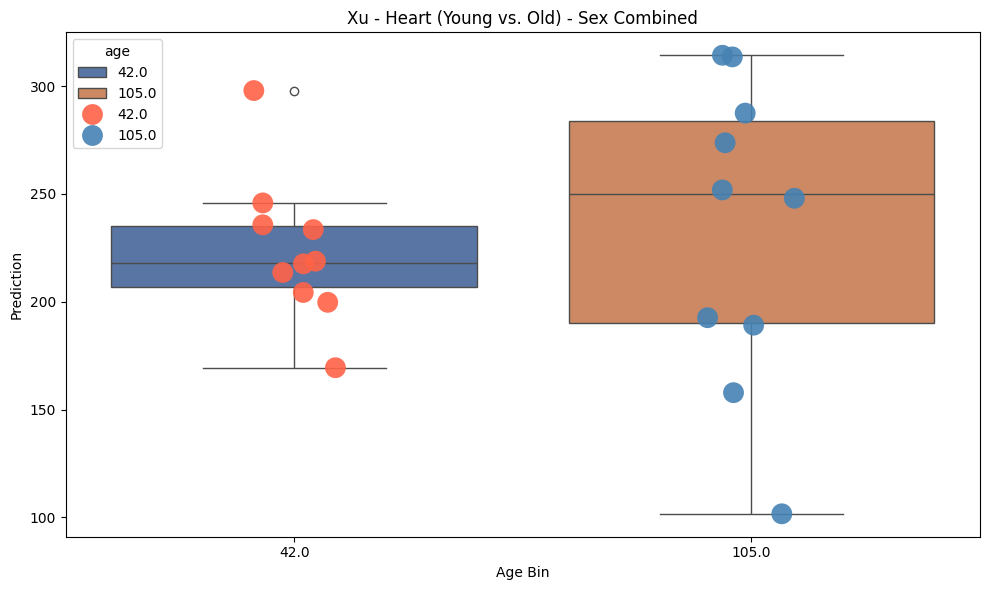

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='age',
    data=df_prediction,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Xu - Heart (Young vs. Old) - Sex Combined')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()